In [3]:
%mamba install pandas

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 2.794 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ pandas                        3.0.1                         np22py313h9d9dc1e_0           emscripten-forge              
+ python-tzdata                 2025.3                        pyhd8ed1ab_0                  conda-forge                   
- pip                           25.3                          pyh145f28c_0                  conda-forge                   


In [110]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Import CAISO actual load data
df_actual = pd.read_csv("1_month_CAISO_load.csv")
# Import CAISO DAM (Day ahead market) forecast 
df_dam = pd.read_csv("1_month_DAM_forecast.csv")
# Import CAISO RTM (Real time market) forecast
df_rtm = pd.read_csv("1_month_RTM_forecast.csv")
# Import CAISO Renewables actual load data
df_renewable = pd.read_csv("1_month_Renewables_Act.csv")

dfs = [df_actual, df_dam, df_rtm, df_renewable]

In [80]:
# Define a function to parse datetime fields and set index
def parse_dates(df): 
    df['start_time'] = pd.to_datetime(df['INTERVALSTARTTIME_GMT'], utc=True, errors='coerce')
    df['end_time'] = pd.to_datetime(df['INTERVALENDTIME_GMT'], utc=True, errors='coerce')

    df = df.set_index('start_time').sort_index()
    print("Missing indexes:" + str(df.index.isna().sum())) 

    df['day'] = df.index.day
    df['weekday'] = df.index.weekday
    df['day_of_week'] = df.index.strftime('%a')

    return df

In [81]:
def add_tac_metadata(df, col='TAC_AREA_NAME'):
    """
    Adds TAC metadata columns:
        - tac_description
        - is_caiso (bool)
        - region_group (str)

    Parameters:
        df (pd.DataFrame)
        col (str): column with TAC names

    Returns:
        pd.DataFrame
    """

    tac_map = {
        # --- CAISO ---
        'PGE-TAC': ('CAISO - PG&E territory (Northern California)', True, 'CAISO'),
        'SCE-TAC': ('CAISO - Southern California Edison', True, 'CAISO'),
        'SDGE-TAC': ('CAISO - San Diego Gas & Electric', True, 'CAISO'),
        'VEA-TAC': ('CAISO - Valley Electric Association', True, 'CAISO'),
        'MWD-TAC': ('CAISO - Metropolitan Water District', True, 'CAISO'),
        'CA ISO-TAC': ('CAISO - Total system load (aggregate)', True, 'CAISO_TOTAL'),

        # --- BANC ---
        'BANC': ('BANC - Balancing Authority of Northern California', False, 'BANC'),
        'BANCWASN': ('BANC - WAPA Sierra Nevada region', False, 'BANC'),
        'BANCSMUD': ('BANC - Sacramento Municipal Utility District', False, 'BANC'),
        'BANCRSVL': ('BANC - City of Roseville', False, 'BANC'),
        'BANCRDNG': ('BANC - City of Redding', False, 'BANC'),
        'BANCMID': ('BANC - Modesto Irrigation District', False, 'BANC'),

        # --- Northwest ---
        'BPAT': ('Bonneville Power Administration', False, 'Northwest'),
        'AVA': ('Avista Utilities', False, 'Northwest'),
        'AVRN': ('Avangrid Renewables', False, 'Northwest'),
        'PSEI': ('Puget Sound Energy', False, 'Northwest'),
        'TPWR': ('Tacoma Power', False, 'Northwest'),
        'SCL': ('Seattle City Light', False, 'Northwest'),
        'IPCO': ('Idaho Power', False, 'Northwest'),
        'PACE': ('PacifiCorp East', False, 'Northwest'),
        'PACW': ('PacifiCorp West', False, 'Northwest'),
        'NWMT': ('NorthWestern Energy (Montana)', False, 'Northwest'),

        # --- Southwest ---
        'AZPS': ('Arizona Public Service', False, 'Southwest'),
        'SRP': ('Salt River Project', False, 'Southwest'),
        'TEPC': ('Tucson Electric Power', False, 'Southwest'),
        'EPE': ('El Paso Electric', False, 'Southwest'),
        'PNM': ('Public Service Company of New Mexico', False, 'Southwest'),
        'NEVP': ('NV Energy (Nevada Power)', False, 'Southwest'),

        # --- California (non-CAISO) ---
        'LADWP': ('Los Angeles Department of Water & Power (non-CAISO)', False, 'CA_NonCAISO'),
        'TIDC': ('Turlock Irrigation District (non-CAISO)', False, 'CA_NonCAISO'),

        # --- WAPA ---
        'WALC': ('WAPA Lower Colorado', False, 'WAPA'),
        'WALCAEPCO': ('WAPA / EPCOR region', False, 'WAPA'),
        'WALCDSW': ('WAPA Desert Southwest', False, 'WAPA'),

        # --- Canada ---
        'BCHA': ('BC Hydro', False, 'Canada'),

        # --- Special ---
        'PGE': ('Portland General Electric (Oregon, non-CAISO)', False, 'Northwest'),
    }

    # Map to tuples
    mapped = df[col].map(tac_map)

    # Expand tuple into columns
    df['tac_description'] = mapped.apply(lambda x: x[0] if pd.notna(x) else 'UNKNOWN')
    df['is_caiso'] = mapped.apply(lambda x: x[1] if pd.notna(x) else False)
    df['region_group'] = mapped.apply(lambda x: x[2] if pd.notna(x) else 'UNKNOWN')

    return df


In [112]:
df_actual = parse_dates(df_actual)
df_dam = parse_dates(df_dam)
df_rtm = parse_dates(df_rtm)
df_renewable = parse_dates(df_renewable)

df_actual = add_tac_metadata(df_actual)
df_dam = add_tac_metadata(df_dam)
df_rtm = add_tac_metadata(df_rtm)


Missing indexes:0
Missing indexes:0
Missing indexes:1
Missing indexes:0


In [116]:
print(df_actual['TAC_AREA_NAME'].unique())
print(df_dam['TAC_AREA_NAME'].unique())
print(df_rtm['TAC_AREA_NAME'].unique())
print(df_renewable['TRADING_HUB'].unique())

<StringArray>
[      'NWMT',       'AVRN',       'IPCO',       'BPAT',    'MWD-TAC',
       'PACW',        'PGE',    'BANCMID',       'TIDC',        'EPE',
        'SRP', 'CA ISO-TAC',  'WALCAEPCO',    'PGE-TAC',       'BANC',
       'AZPS',       'PSEI',        'PNM',      'LADWP',   'SDGE-TAC',
       'BCHA',   'BANCRDNG',       'TPWR',    'WALCDSW',       'WALC',
        'SCL',   'BANCSMUD',    'SCE-TAC',       'TEPC',       'PACE',
   'BANCRSVL',       'NEVP',    'VEA-TAC',        'AVA',   'BANCWASN']
Length: 35, dtype: str
<StringArray>
[  'BANCWASN',    'BANCMID',   'SDGE-TAC',       'PACW',        'EPE',
   'BANCRSVL',    'MWD-TAC',       'NEVP',       'NWMT',    'WALCDSW',
    'PGE-TAC',        'SCL',       'BANC',        'PNM',  'WALCAEPCO',
       'TIDC',       'PACE',       'AVRN',       'IPCO',       'BPAT',
   'BANCRDNG',       'TPWR',    'VEA-TAC',   'BANCSMUD',       'TEPC',
    'SCE-TAC',        'PGE',      'LADWP', 'CA ISO-TAC',        'SRP',
       'PSEI',        'AVA

In [73]:
print(df_dam.describe())
print(df_rtm.describe())
print(df_actual.describe())

# print(df_dam.loc[df_dam['MW'].idxmax()])
# print(df_rtm.loc[df_dam['MW'].idxmax()])
# print(df_actual.loc[df_actual['MW'].idxmax()])

       LOAD_TYPE        OPR_HR  OPR_INTERVAL           POS            MW  \
count    25296.0  25296.000000       25296.0  25296.000000  25296.000000   
mean         1.0     12.500000           0.0      2.702941   2847.148265   
std          0.0      6.922323           0.0      0.221610   4485.289902   
min          1.0      1.000000           0.0      2.000000      0.000000   
25%          1.0      6.750000           0.0      2.800000    308.387500   
50%          1.0     12.500000           0.0      2.800000   1434.135000   
75%          1.0     18.250000           0.0      2.800000   3096.962500   
max          1.0     24.000000           0.0      2.800000  29159.950000   

              GROUP           day       weekday  
count  25296.000000  25296.000000  25296.000000  
mean     527.500000     16.000000      2.838710  
std      304.269469      8.944449      1.985418  
min        1.000000      1.000000      0.000000  
25%      264.000000      8.000000      1.000000  
50%      527.50

In [107]:
print(df_actual['MW'].idxmax())
print(df_actual.idxmax())

2025-12-10 17:00:00+00:00
INTERVALSTARTTIME_GMT   2026-01-01 07:00:00+00:00
INTERVALENDTIME_GMT     2026-01-01 07:00:00+00:00
LOAD_TYPE               2025-12-01 08:00:00+00:00
OPR_DT                  2025-12-31 08:00:00+00:00
OPR_HR                  2025-12-02 07:00:00+00:00
OPR_INTERVAL            2025-12-01 08:00:00+00:00
MARKET_RUN_ID           2025-12-01 08:00:00+00:00
TAC_AREA_NAME           2025-12-01 08:00:00+00:00
LABEL                   2025-12-01 08:00:00+00:00
XML_DATA_ITEM           2025-12-01 08:00:00+00:00
POS                     2025-12-01 08:00:00+00:00
MW                      2025-12-10 17:00:00+00:00
EXECUTION_TYPE          2025-12-01 08:00:00+00:00
GROUP                   2025-12-31 08:00:00+00:00
end_time                2026-01-01 07:00:00+00:00
day                     2025-12-31 00:00:00+00:00
weekday                 2025-12-07 00:00:00+00:00
day_of_week             2025-12-03 00:00:00+00:00
tac_description         2025-12-01 08:00:00+00:00
is_caiso                

In [ ]:
"""
# Average hourly shape
df.groupby(df.index.hour)['MW'].mean()
# Weekday vs Weekend
df.groupby(df.index.dayofweek)['MW'].mean()
#Forecast error distribution
(df['MW_actual'] - df['MW_rtm']).hist()
"""

In [115]:
def time_series_checks(df):
    # Confirm frequency consistency
    print("Index frequency: "+ str(pd.infer_freq(df.index)))
    
    # Check for duplicate timestamps
    print("Duplicate timestamps: "+ str(df.index.duplicated().sum()))
    
    # Find sequences of consecutive NaN values and count how long each sequence is
    result = df['MW'].isna().astype(int).groupby(
        df['MW'].notna().cumsum()
    ).sum()
    print("Sequences of consecutive NaN values: ")
    print(result[result > 0])
    print("\n")

time_series_checks(df_dam)
time_series_checks(df_rtm)
time_series_checks(df_actual)
time_series_checks(df_renewable)

Index frequency: None
Duplicate timestamps: 24552
Sequences of consecutive NaN values: 
Series([], Name: MW, dtype: int32)


Index frequency: None
Duplicate timestamps: 241407
Sequences of consecutive NaN values: 
MW
246877    1
Name: MW, dtype: int32


Index frequency: None
Duplicate timestamps: 25296
Sequences of consecutive NaN values: 
Series([], Name: MW, dtype: int32)


Index frequency: None
Duplicate timestamps: 3715
Sequences of consecutive NaN values: 
Series([], Name: MW, dtype: int32)




In [117]:
""" Analyze CAISO Area Total MW Forecast and Actuals """

# Pivot hourly Actual
df_filtered = df_actual[df_actual['TAC_AREA_NAME'] == 'CA ISO-TAC']
pivot_hrly_actual = (
    df_filtered
    .pivot_table(index=df_filtered.index, values='MW', aggfunc='sum')
    .round(2)
)

# Pivot hourly DAM
df_filtered_2 = df_dam[df_dam['TAC_AREA_NAME'] == 'CA ISO-TAC']
pivot_hrly_dam = (
    df_filtered_2
    .pivot_table(index=df_filtered_2.index, values='MW', aggfunc='sum')
    .round(2)
)

# Pivot hourly RTM
df_filtered_3 = df_rtm[(df_rtm['TAC_AREA_NAME'] == 'CA ISO-TAC') & (df_rtm['LABEL'] == 'RTM 15Min Load Forecast')]
pivot_hrly_rtm = (
    df_filtered_3
    .pivot_table(index=df_filtered_3.index, values='MW', aggfunc='sum')
    .round(2)
)

# Pivot hourly Renewables
pivot_hrly_renewable = (
    df_renewable
    .pivot_table(index=df_renewable.index, values='MW', aggfunc='sum')
    .round(2)
)

In [103]:
def plot_hrly_forecast(ax, df, label):
    ax.plot(df.index, df['MW'], alpha=0.6, label=label)

    ax.set_title('Hourly Load (UTC)')
    ax.set_ylabel('MW')
    ax.grid(True, axis='y', alpha=0.4)
    ax.legend()

    ax.xaxis.set_major_locator(mdates.DayLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    fig.autofmt_xdate()

#plot_hrly_forecast(ax, pivot_hrly_dam, 'DAM')
#plot_hrly_forecast(ax, pivot_hrly_actual, 'Actual')

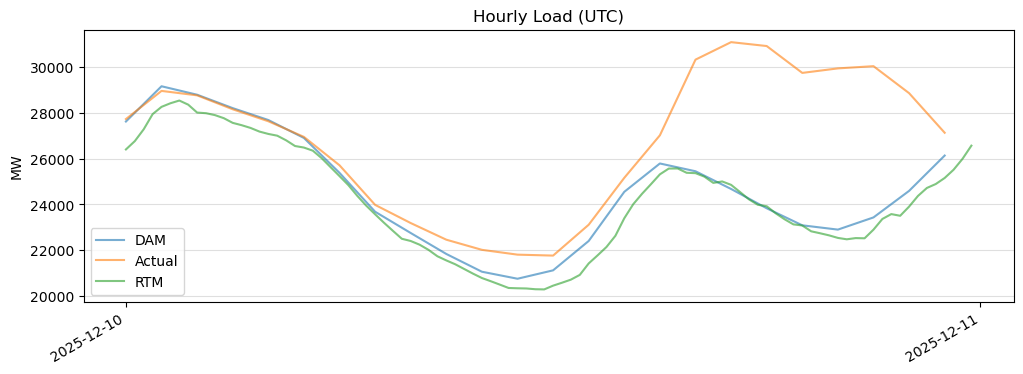

In [121]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_hrly_forecast(ax, pivot_hrly_dam.loc['2025-12-10'], 'DAM')
plot_hrly_forecast(ax, pivot_hrly_actual.loc['2025-12-10'], 'Actual')
plot_hrly_forecast(ax, pivot_hrly_rtm.loc['2025-12-10'], 'RTM')
#plot_hrly_forecast(ax, pivot_hrly_renewable.loc['2025-12-10'], 'Renewable')

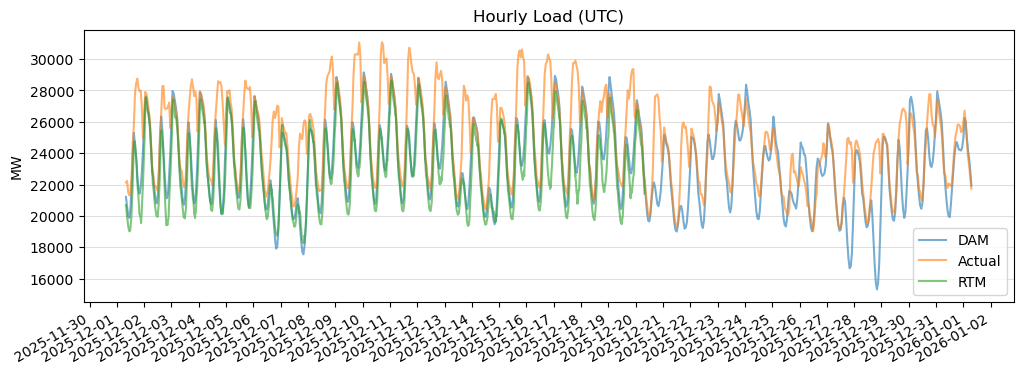

In [120]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_hrly_forecast(ax, pivot_hrly_dam, 'DAM')
plot_hrly_forecast(ax, pivot_hrly_actual, 'Actual')
plot_hrly_forecast(ax, pivot_hrly_rtm, 'RTM')
#plot_hrly_forecast(ax, pivot_hrly_renewable, 'Renewable')

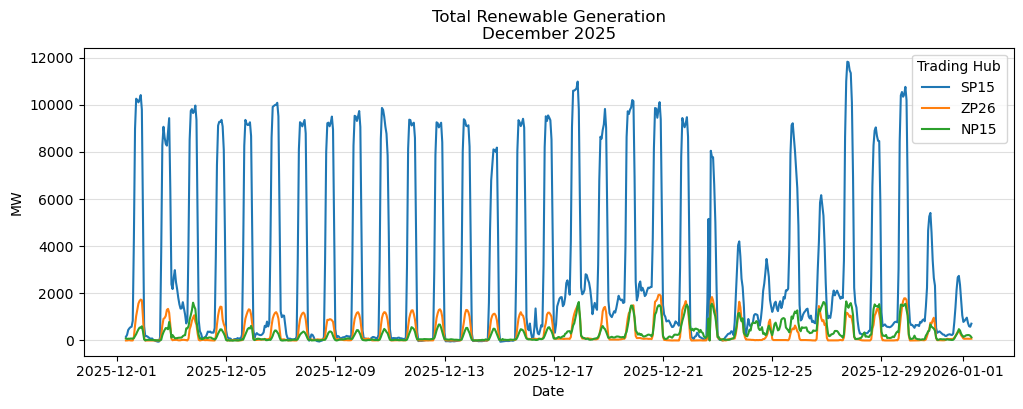

In [126]:
# Plot renewable generation by location 
fig, ax = plt.subplots(figsize=(12,4))

"""
for hub, g in df_renewable.groupby('TRADING_HUB', sort=False):
    ax.plot(g.index, g['MW'], label=hub)
"""

for hub, g in df_renewable.groupby('TRADING_HUB', sort=False):
    g_resampled = g.sort_index().resample('1h')['MW'].sum()
    ax.plot(g_resampled.index, g_resampled, label=hub)

ax.set_xlabel('Date')
ax.set_ylabel('MW')
ax.set_title('Total Renewable Generation\nDecember 2025')

#ax.set_xticks(range(0, 24))
ax.legend(title='Trading Hub')

ax.grid(True, axis='y', alpha=0.4)

plt.show()

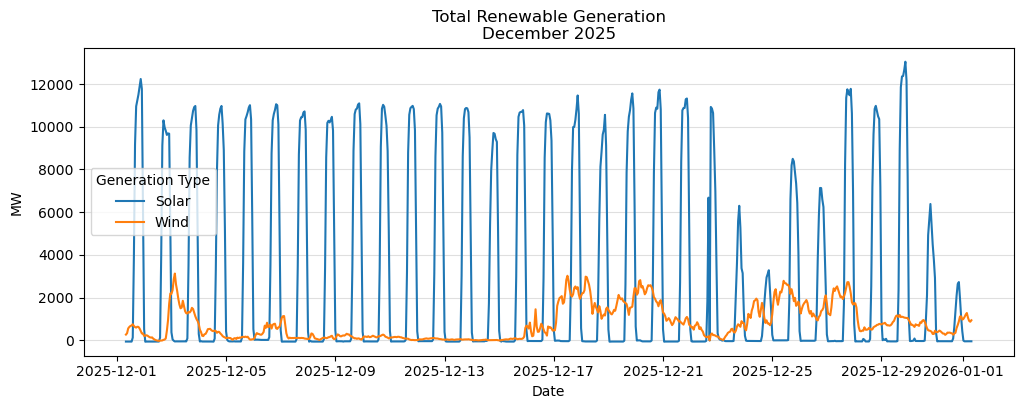

In [127]:
# Plot renewable generation by type 
fig, ax = plt.subplots(figsize=(12,4))

"""
for hub, g in df_renewable.groupby('TRADING_HUB', sort=False):
    ax.plot(g.index, g['MW'], label=hub)
"""

for hub, g in df_renewable.groupby('RENEWABLE_TYPE', sort=False):
    g_resampled = g.sort_index().resample('1h')['MW'].sum()
    ax.plot(g_resampled.index, g_resampled, label=hub)

ax.set_xlabel('Date')
ax.set_ylabel('MW')
ax.set_title('Total Renewable Generation\nDecember 2025')

#ax.set_xticks(range(0, 24))
ax.legend(title='Generation Type')

ax.grid(True, axis='y', alpha=0.4)

plt.show()